In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import jieba.analyse

In [27]:
path='.\\AC\\'
filename='1768545415.7469118Cleaned办公室空调_清洗后.csv'

In [28]:
df=pd.read_csv(path+filename,encoding='utf-8')

In [29]:
df.head()

,Unnamed: 0,Name,Date,Content
0,0,我是HRD豆爸,2016年01月15日 18:36 来自 天生会转 OPPO N3,感冒 ， 空调 给力，阿姨熬 一碗暖暖 “冰糖雪梨”，感动ing
1,3,YouTube易烊千玺频道,09月16日 20:28 来自 易烊千玺超话,易烊千玺垒石十五分钟纯 LYouTube易烊千玺频道 视频
2,5,用户5557314247,2016年02月01日 21:28 来自 专业版微博,这 一间 平米 ，阴暗潮湿，杂乱破旧，天花板严重开裂，中央空调管道暴露 外，随时 有掉落 危...
3,6,TFBOYS-易烊千玺,09月16日 20:01 来自 微博直播平台,TFBOYS-易烊千玺 直播
4,7,张星特闭麦吗,09月16日 20:16 来自 微博视频号,这支纪录片发布后属于 . . 记忆 会被永远封存 们 记忆 感谢 们愿意陪 一起参与这场...


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28631 entries, 0 to 28630
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  28631 non-null  int64 
 1   Name        28631 non-null  object
 2   Date        28631 non-null  object
 3   Content     28631 non-null  object
dtypes: int64(1), object(3)
memory usage: 894.8+ KB


In [7]:
def winter(month):
    if month==1 or month==2 or month==12 or month==11:
        return True
    else:
        return False

In [8]:
def count_phrase_occurrences(text, phrase):  
    """  
    统计词组在字符串中出现的次数  
  
    :param text: 待搜索的字符串  
    :param phrase: 要统计的词组  
    :return: 词组在字符串中出现的次数  
    """  
    return text.count(phrase)

In [9]:
#df=df[df['Month'].apply(winter)]

In [10]:
content = " ".join(df["Content"].dropna())
#wordcloud1.generate(content)
tags = jieba.analyse.extract_tags(content, topK=200, withWeight=False)
stopwords = pd.read_csv("stopwords.txt",encoding= 'utf8',index_col=False)
stopwords_list=stopwords['stopword'].values
new_tags=[]
for tag in tags:
    if tag not in stopwords_list:
        new_tags.append(tag)
text =" ".join(new_tags)
print(text)

Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\tzcha\AppData\Local\Temp\jieba.cache
Loading model cost 0.747 seconds.
Prefix dict has been built successfully.


空调 上班 冬天 同事 感觉 暖和 没有 每天 早上 时候 暖气 觉得 羽绒服 自己 温度 下午 一天 工作 下班 这个 然后 因为 这么 中午 感冒 老师 冻死 太冷 天气 有点 怎么 晚上 中央空调 可以 打开 加班 夏天 昨天 一直 瑟瑟 发抖 回家 开始 什么 知道 第一天 舒服 为什么 领导 小时 外套 起来 最近 外面 发现 喜欢 一样 一下 已经 热死 睡觉 公司 窗户 制热 一点 还有 制冷 明天 结果 终于 天天 几天 大家 口罩 冻得 老板 太阳 冷风 怕冷 特别 电脑 冷死 出门 手机 开心 单位 工位 突然 那么 温暖 室内 视频 宿舍 学校 零下 衣服 好像 两天 之前 降温 给力 厕所 加湿器 取暖 太热 所以 放假 两个 以为 虽然 还开 暖风机 干燥 很多 难受 短袖 整个 秋裤 生活 只有 回来 出来 可能 摸鱼 空气 还好 直接 教室 有人 暖风 看到 最后 时间 上午 毛衣 食堂 热水袋 一起 取暖器 有个 热水 值班 只能 这样 快乐 抽烟 本来 居然 吃饭 热得 冰窖 味道 他们 一整天 外卖 午休 应该 没开 路上 修好 开窗 东西 冷到 疫情 皮肤 房间 宝宝 遥控器 希望 室外 学生 冷得 超级 出去 之后 讨厌 每次 热到 问题 别人 起床 昨晚 好吃 发烧 感受 容易 幸福 朋友 喷雾 其实 气温 通风 那个 到现 热风 环境 风扇 事情 准备 隔壁


In [11]:
i=1
word_dict={}
for tag in new_tags:
    if tag not in stopwords and i<=100:
        num_count=count_phrase_occurrences(content,tag)
        word_dict[tag]=num_count
    i+=1
print(word_dict)

{'空调': 10518, '上班': 1010, '冬天': 884, '同事': 832, '感觉': 992, '暖和': 566, '没有': 1481, '每天': 712, '早上': 586, '时候': 1073, '暖气': 489, '觉得': 789, '羽绒服': 342, '自己': 1016, '温度': 585, '下午': 612, '一天': 948, '工作': 847, '下班': 411, '这个': 835, '然后': 619, '因为': 711, '这么': 625, '中午': 431, '感冒': 390, '老师': 470, '冻死': 301, '太冷': 274, '天气': 480, '有点': 526, '怎么': 684, '晚上': 511, '中央空调': 227, '可以': 695, '打开': 406, '加班': 263, '夏天': 347, '昨天': 488, '一直': 517, '瑟瑟': 237, '发抖': 281, '回家': 402, '开始': 599, '什么': 1122, '知道': 570, '第一天': 274, '舒服': 316, '为什么': 408, '领导': 409, '小时': 466, '外套': 223, '起来': 587, '最近': 342, '外面': 304, '发现': 453, '喜欢': 333, '一样': 431, '一下': 482, '已经': 544, '热死': 186, '睡觉': 267, '公司': 537, '窗户': 231, '制热': 160, '一点': 461, '还有': 453, '制冷': 185, '明天': 262, '结果': 339, '终于': 309, '天天': 270, '几天': 283, '大家': 335, '口罩': 181, '冻得': 184, '老板': 252, '太阳': 293, '冷风': 236, '怕冷': 152, '特别': 308, '电脑': 222, '冷死': 130, '出门': 220, '手机': 238, '开心': 188, '单位': 266, '工位': 119, '突然': 273, '那么': 297, '温暖': 20

In [12]:
word_dict.keys()

dict_keys(['空调', '上班', '冬天', '同事', '感觉', '暖和', '没有', '每天', '早上', '时候', '暖气', '觉得', '羽绒服', '自己', '温度', '下午', '一天', '工作', '下班', '这个', '然后', '因为', '这么', '中午', '感冒', '老师', '冻死', '太冷', '天气', '有点', '怎么', '晚上', '中央空调', '可以', '打开', '加班', '夏天', '昨天', '一直', '瑟瑟', '发抖', '回家', '开始', '什么', '知道', '第一天', '舒服', '为什么', '领导', '小时', '外套', '起来', '最近', '外面', '发现', '喜欢', '一样', '一下', '已经', '热死', '睡觉', '公司', '窗户', '制热', '一点', '还有', '制冷', '明天', '结果', '终于', '天天', '几天', '大家', '口罩', '冻得', '老板', '太阳', '冷风', '怕冷', '特别', '电脑', '冷死', '出门', '手机', '开心', '单位', '工位', '突然', '那么', '温暖', '室内', '视频', '宿舍', '学校', '零下', '衣服', '好像', '两天', '之前', '降温'])

In [13]:
content_array=df['Content'].values

In [14]:
keywords_list=[['吸烟','烟味','二手烟','抽烟','烟雾'],['发烧','感冒','难受','头晕','头疼','安眠药'],['冷死','不冷','太冷','冷风'],['不透气','甲醛','味道','污染']]
#keywords=['发烧','感冒','难受','头晕','头疼','安眠药']
#keywords=['冷死','不冷','太冷','冷风']
#keywords=['不透气','甲醛','味道','污染']
i=0
for keywords in keywords_list:
    for content in content_array:
        for keyword in keywords:
            if keyword in str(content):
                i+=1
                break
    print(keywords,filename,f'{i/len(content_array)}') 

['吸烟', '烟味', '二手烟', '抽烟', '烟雾'] 3.9216winter1768545415.7469118Cleaned办公室空调_清洗后.csv 0.012943751784524603
['发烧', '感冒', '难受', '头晕', '头疼', '安眠药'] 3.9216winter1768545415.7469118Cleaned办公室空调_清洗后.csv 0.0715713333967831
['冷死', '不冷', '太冷', '冷风'] 3.9216winter1768545415.7469118Cleaned办公室空调_清洗后.csv 0.12620157989911487
['不透气', '甲醛', '味道', '污染'] 3.9216winter1768545415.7469118Cleaned办公室空调_清洗后.csv 0.13885980774721615


In [15]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import defaultdict, Counter
from collections import Counter, defaultdict
import re

In [16]:
sentences=content_array.tolist()

In [17]:
# ===================== 2. 中文分词 =====================
# 对每个句子进行分词（去掉空格，统一处理）
tokenized_sentences = []
for sent in sentences:
    # jieba 分词 + 去除空字符串
    if type(sent)==str:
        words = [word for word in jieba.lcut(sent.replace(" ", "")) if word.strip()]
        tokenized_sentences.append(words)

In [46]:
vocab=['冬天','感冒', '感觉', '暖和', '没有', '每天', '时候', '暖气', '觉得', '温度', '一天', '这个', '然后',
       '因为', '太冷', '怎么', '可以', '打开', '夏天', '一直', '什么', '知道', '为什么']

In [47]:
# ===================== 4. 构建共现矩阵 =====================
# 初始化矩阵为 0
vocab_size=len(vocab)
co_matrix = np.zeros((vocab_size, vocab_size), dtype=int)
word_to_idx = {word: i for i, word in enumerate(vocab)}
# 窗口大小：表示一个词左右各看几个词（常用 2 或 1）
window_size = 1



=== 词共现矩阵 ===
     冬天  感冒  感觉  暖和  没有  每天  时候  暖气  觉得  温度  ...  因为  太冷  怎么  可以  打开  夏天  一直  \
冬天    0   0   5   3  11   3   4   7   7   2  ...   2   2  13   2   1   4   3   
感冒    0   4   4   0   2   1   0   0   1   0  ...   4   0   1   0   0   0   1   
感觉    5   4   0   4   9   8  12   3   0   1  ...   3   3   8   0   0   2   2   
暖和    3   0   4  18   3   0   3   2   9   1  ...   3   0   2   0   1   1   1   
没有   11   2   9   3   6   1   7  63   8   6  ...  12   3   5   2   3   3   5   
每天    3   1   8   0   1   0   1   0   7   2  ...   2   1   2   8   0   0   0   
时候    4   0  12   3   7   1   0   1  14   2  ...   1   0   4  10   3   9   2   
暖气    7   0   3   2  63   0   1   0   0   0  ...   2   0   1   1   1   1   2   
觉得    7   1   0   9   8   7  14   0   0   2  ...   1   2   4   6   0   1  16   
温度    2   0   1   1   6   2   2   0   2   0  ...   2   0   0   5   0   1   2   
一天    0   4   6   1  11   1   1   0   1   1  ...   1   0   2   0   0   0   0   
这个   62   0   4   2   6  

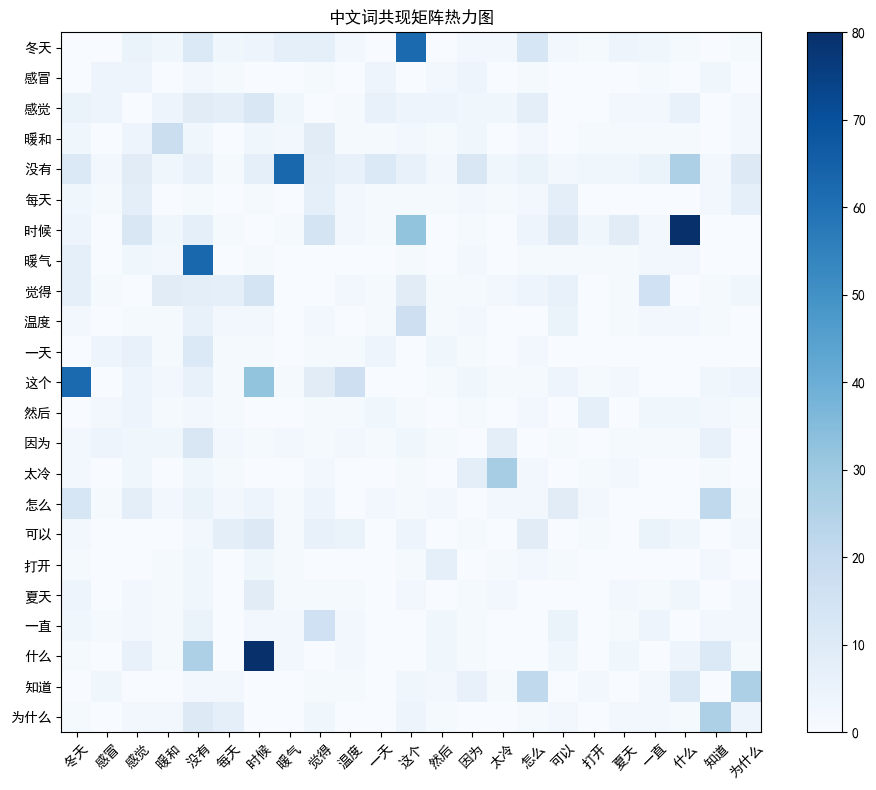

In [48]:
from pylab import mpl
mpl.rcParams['font.sans-serif'] = ['SimHei']
mpl.rcParams['axes.unicode_minus'] = False
for sent in tokenized_sentences:
    sent_len = len(sent)
    for i, target_word in enumerate(sent):
        # 遍历窗口内的上下文词
        if target_word in vocab:
            for j in range(max(0, i - window_size), min(sent_len, i + window_size + 1)):
                if i != j:  # 不计算自己和自己
                    context_word = sent[j]
                    if context_word in word_to_idx:
                        # 获取索引
                        target_idx = word_to_idx[target_word]
                        context_idx = word_to_idx[context_word]
                        # 计数 +1
                        co_matrix[target_idx][context_idx] += 1

# ===================== 5. 展示矩阵 =====================
df = pd.DataFrame(co_matrix, index=vocab, columns=vocab)

print("\n=== 词共现矩阵 ===")
print(df)

# ===================== 6. 可视化矩阵 =====================
plt.figure(figsize=(10, 8))
plt.imshow(co_matrix, cmap="Blues")
plt.colorbar()
plt.xticks(range(vocab_size), vocab, rotation=45)
plt.yticks(range(vocab_size), vocab)
plt.title("中文词共现矩阵热力图")
plt.tight_layout()
plt.show()

In [24]:
df['感冒'].describe()

count    50.000000
mean      1.220000
std       1.887553
min       0.000000
25%       0.000000
50%       0.000000
75%       1.750000
max       9.000000
Name: 感冒, dtype: float64

In [30]:
df_ganmao=df.groupby(by=['空调']).sum()

In [34]:
df_ganmao

,上班,冬天,同事,感觉,暖和,没有,每天,早上,时候,暖气,...,发抖,回家,开始,什么,知道,第一天,舒服,为什么,领导,小时
空调,,,,,,,,,,,,,,,,,,,,,
3,7,1,6,5,0,4,7,3,28,0,...,1,27,2,0,5,1,0,1,0,5
5,4,2,1,1,1,10,14,0,13,0,...,1,13,8,0,1,0,2,0,3,1
6,3,2,0,2,0,2,0,0,0,0,...,0,0,0,0,1,0,1,0,0,0
7,0,4,1,1,0,4,1,0,0,1,...,227,0,1,0,4,0,0,1,0,0
8,8,2,6,5,10,8,1,2,5,0,...,0,2,18,5,7,4,1,6,4,2
9,1,1,1,5,6,1,1,0,0,1,...,0,1,2,0,0,1,4,1,0,0
10,24,60,20,119,51,230,38,22,37,70,...,6,21,21,26,51,19,9,29,15,22
11,0,0,7,4,1,7,8,2,8,1,...,1,0,7,7,2,3,1,1,5,2
13,1,2,2,2,11,5,4,0,1,2,...,0,0,1,0,1,2,2,18,1,0


In [40]:
df_ganmao.iloc[6]>30

上班      False
冬天       True
同事      False
感觉       True
暖和       True
没有       True
每天       True
早上      False
时候       True
暖气       True
觉得       True
羽绒服     False
自己      False
温度       True
下午      False
一天       True
工作      False
下班      False
这个       True
然后       True
因为       True
这么      False
中午      False
感冒      False
老师      False
冻死      False
太冷       True
天气      False
有点      False
怎么       True
晚上      False
中央空调    False
可以      False
打开       True
加班      False
夏天       True
昨天      False
一直       True
瑟瑟      False
发抖      False
回家      False
开始      False
什么      False
知道       True
第一天     False
舒服      False
为什么     False
领导      False
小时      False
Name: 10, dtype: bool

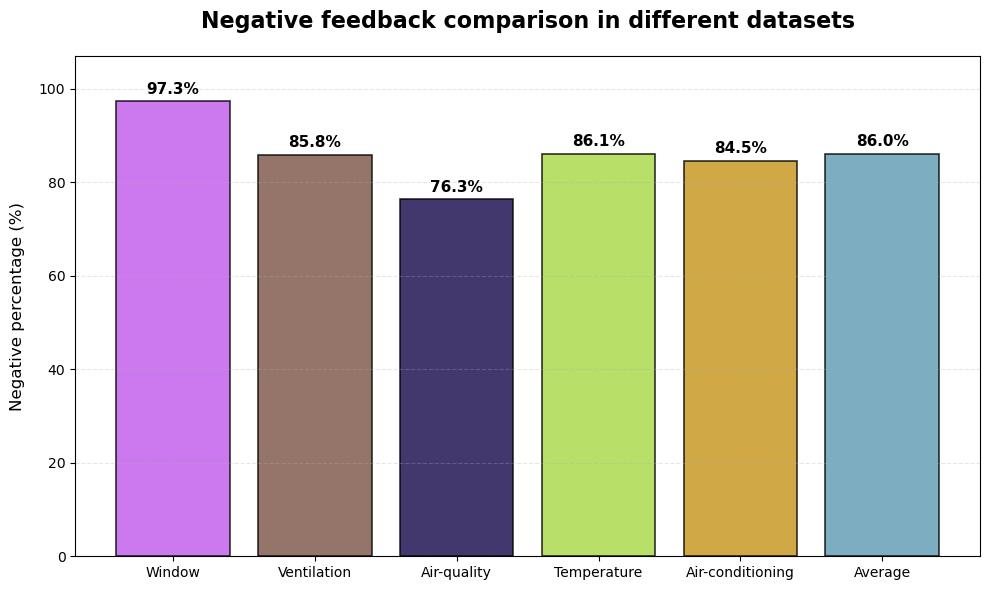

In [10]:
import random
import time
# 示例数据（字典格式）
data_dict = {
    'Window': 97.3,
    'Ventilation': 85.8,
    'Air-quality': 76.3,
    'Temperature': 86.1,
    'Air-conditioning':84.5,
    'Average':86.0
}
random_color1 = (random.random(), random.random(), random.random())
random_color2 = (random.random(), random.random(), random.random())
random_color3 = (random.random(), random.random(), random.random())
random_color4 = (random.random(), random.random(), random.random())
random_color5 = (random.random(), random.random(), random.random())
random_color6 = (random.random(), random.random(), random.random())
colors_manual = [random_color1, random_color2, random_color3, random_color4,random_color5,random_color6]
# 从字典中提取键和值
categories = list(data_dict.keys())  # 类别名称（x轴）
values = list(data_dict.values())      # 数值（y轴）

# 创建图形和轴对象
plt.figure(figsize=(10, 6))

# 绘制柱状图
bars = plt.bar(categories, values, 
               color=colors_manual,     # 柱子颜色
               edgecolor='black',    # 边框颜色
               linewidth=1.2,        # 边框宽度
               alpha=0.8)            # 透明度

# 添加数值标签（在每个柱子上方显示数值）
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height}%',  # 显示整数
             ha='center', va='bottom',
             fontsize=11, fontweight='bold')

# 设置标题和轴标签
plt.title('Negative feedback comparison in different datasets', fontsize=16, fontweight='bold', pad=20)
#plt.xlabel('In different datasets', fontsize=12, labelpad=10)
plt.ylabel('Negative percentage (%)', fontsize=12, labelpad=10)

# 设置y轴范围（留出空间显示标签）
plt.ylim(0, max(values) * 1.1)

# 添加网格线（仅在y轴）
plt.grid(axis='y', alpha=0.3, linestyle='--')

# 旋转x轴标签（如果类别过多可启用）
# plt.xticks(rotation=45, ha='right')

# 调整布局防止标签被裁剪
plt.tight_layout()
# 可选：保存图片
#plt.savefig(str(time.time())[-6:]+'negative_feedback_barchart.png', dpi=300, bbox_inches='tight')
# 显示图表
plt.show()